In [1]:
import os, pandas as pd, numpy as np, matplotlib.pyplot as plt
os.chdir(os.path.expanduser("~/growth-marketing-analytics"))
p, OUT = "data/raw/olist/", "module_3_olist/outputs/"

orders = pd.read_csv(p + "olist_orders_dataset.csv", parse_dates=["order_purchase_timestamp"])
cust   = pd.read_csv(p + "olist_customers_dataset.csv")
pay    = pd.read_csv(p + "olist_order_payments_dataset.csv")

o = (orders[orders.order_status == "delivered"]
       .merge(cust[["customer_id","customer_unique_id","customer_state"]], on="customer_id")
       .merge(pay.groupby("order_id").payment_value.sum().rename("order_value"),
              left_on="order_id", right_index=True))
o = o[o.order_purchase_timestamp >= "2017-01-01"]
print(o.shape, o.order_purchase_timestamp.min().date(), "to", o.order_purchase_timestamp.max().date())

(96211, 11) 2017-01-05 to 2018-08-29


In [2]:
c = o.groupby("customer_unique_id").agg(
    orders=("order_id","count"), revenue=("order_value","sum"),
    first=("order_purchase_timestamp","min"), last=("order_purchase_timestamp","max"))
rep = c.orders > 1
print(f"""
Customers:                 {len(c):,}
Orders:                    {len(o):,}
Revenue:                   R$ {o.order_value.sum():,.0f}
AOV:                       R$ {o.order_value.mean():,.2f}
Median order value:        R$ {o.order_value.median():,.2f}
Repeat purchase rate:      {rep.mean():.1%}
Revenue from repeaters:    {c[rep].revenue.sum()/c.revenue.sum():.1%}
Avg revenue per customer:  R$ {c.revenue.mean():,.2f}  (simple LTV)
Repeater vs one-time value:R$ {c[rep].revenue.mean():,.0f} vs R$ {c[~rep].revenue.mean():,.0f}
""")


Customers:                 93,104
Orders:                    96,211
Revenue:                   R$ 15,375,875
AOV:                       R$ 159.81
Median order value:        R$ 105.28
Repeat purchase rate:      3.0%
Revenue from repeaters:    5.6%
Avg revenue per customer:  R$ 165.15  (simple LTV)
Repeater vs one-time value:R$ 309 vs R$ 161



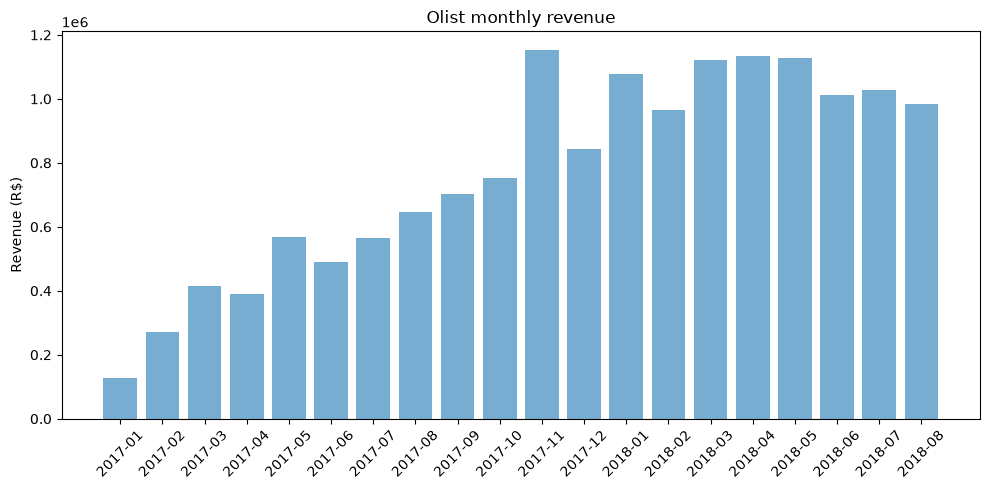

,revenue,orders,new_customers
2018-03,1120678.00,7003,6775
2018-04,1132933.95,6798,6582
2018-05,1128836.69,6749,6508
2018-06,1012090.68,6099,5879
2018-07,1027903.86,6159,5949
2018-08,985414.28,6351,6144


In [3]:
o["month"] = o.order_purchase_timestamp.dt.to_period("M")
c["first_month"] = c["first"].dt.to_period("M")
mt = pd.DataFrame({"revenue": o.groupby("month").order_value.sum(),
                   "orders": o.groupby("month").size(),
                   "new_customers": c.groupby("first_month").size()}).fillna(0)
mt.to_csv(OUT + "monthly_customers.csv")

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(mt.index.astype(str), mt.revenue, alpha=0.6)
ax.set_ylabel("Revenue (R$)"); ax.set_title("Olist monthly revenue")
plt.setp(ax.get_xticklabels(), rotation=45)
plt.tight_layout(); plt.savefig(OUT + "monthly_revenue.png", dpi=150); plt.show()
mt.tail(6)

In [4]:
snap = o.order_purchase_timestamp.max() + pd.Timedelta(days=1)
c["recency"] = (snap - c["last"]).dt.days
hi = c.revenue.quantile(0.75)

def segment(r):
    if r.orders >= 2 and r.recency <= 180: return "1 Champions (repeat, recent)"
    if r.orders >= 2:                      return "2 Loyal but lapsing"
    if r.recency <= 90 and r.revenue >= hi:return "3 New high-value"
    if r.recency <= 90:                    return "4 New"
    if r.revenue >= hi:                    return "5 High-value, at risk"
    return "6 Lost / one-off"

c["segment"] = c.apply(segment, axis=1)
seg = c.groupby("segment").agg(customers=("orders","count"),
        avg_recency_days=("recency","mean"), avg_orders=("orders","mean"),
        avg_revenue=("revenue","mean"), revenue=("revenue","sum"))
seg["customer_share_%"] = seg.customers / seg.customers.sum() * 100
seg["revenue_share_%"]  = seg.revenue / seg.revenue.sum() * 100
seg = seg.round(1)
seg.to_csv(OUT + "rfm_segments.csv")
seg

,customers,avg_recency_days,avg_orders,avg_revenue,revenue,customer_share_%,revenue_share_%
segment,,,,,,,
"1 Champions (repeat, recent)",1231,91.0,2.2,321.0,395179.6,1.3,2.6
2 Loyal but lapsing,1558,321.2,2.1,298.8,465575.0,1.7,3.0
3 New high-value,4324,46.2,1.0,394.8,1706959.5,4.6,11.1
4 New,13522,44.4,1.0,89.4,1209455.5,14.5,7.9
"5 High-value, at risk",17189,283.9,1.0,389.6,6696404.8,18.5,43.6
6 Lost / one-off,55280,284.8,1.0,88.7,4902301.1,59.4,31.9


In [5]:
o2 = o.merge(c[["first_month"]], left_on="customer_unique_id", right_index=True)
o2["age"] = (o2.month - o2.first_month).apply(lambda x: x.n)
tab = o2.groupby(["first_month","age"]).customer_unique_id.nunique().unstack(fill_value=0)
ret = (tab.div(tab[0], axis=0) * 100).iloc[:-3, 1:7].round(2)
ret.columns = [f"M+{k}" for k in ret.columns]
ret.to_csv(OUT + "customer_cohort_retention.csv")
print("Average % of customers buying again in months 1–6:")
print(ret.mean().round(2))
ret

Average % of customers buying again in months 1–6:
M+1    0.48
M+2    0.34
M+3    0.25
M+4    0.27
M+5    0.20
M+6    0.22
dtype: float64


,M+1,M+2,M+3,M+4,M+5,M+6
first_month,,,,,,
2017-01,0.28,0.28,0.14,0.42,0.14,0.42
2017-02,0.18,0.31,0.12,0.43,0.12,0.25
2017-03,0.44,0.36,0.40,0.36,0.16,0.16
2017-04,0.62,0.22,0.18,0.27,0.27,0.35
2017-05,0.46,0.46,0.29,0.29,0.32,0.41
2017-06,0.49,0.40,0.43,0.30,0.40,0.36
2017-07,0.53,0.35,0.24,0.29,0.21,0.32
2017-08,0.69,0.35,0.27,0.35,0.52,0.30
2017-09,0.70,0.55,0.27,0.45,0.22,0.22


In [6]:
st = o.groupby("customer_state").agg(orders=("order_id","count"), revenue=("order_value","sum"))
st["revenue_share_%"] = st.revenue / st.revenue.sum() * 100
st["aov"] = st.revenue / st.orders
st = st.sort_values("revenue", ascending=False).head(10).round(1)
st.to_csv(OUT + "top_states.csv")
st

,orders,revenue,revenue_share_%,aov
customer_state,,,,
SP,40406,5756706.3,37.4,142.5
RJ,12310,2046698.1,13.3,166.3
MG,11319,1814317.8,11.8,160.3
RS,5328,858904.3,5.6,161.2
PR,4903,779319.6,5.1,158.9
SC,3537,592707.7,3.9,167.6
BA,3253,590949.6,3.8,181.7
DF,2074,344946.1,2.2,166.3
GO,1950,333238.1,2.2,170.9


In [7]:
print(f"""
Repeat purchase rate: {rep.mean():.1%}
Largest segment: {seg.customers.idxmax()} ({seg['customer_share_%'].max():.1f}% of customers)
Champions: {seg.loc[seg.index.str.startswith('1'),'customer_share_%'].sum():.1f}% of customers, {seg.loc[seg.index.str.startswith('1'),'revenue_share_%'].sum():.1f}% of revenue
Top state: {st.index[0]} ({st['revenue_share_%'].iloc[0]:.1f}% of revenue)
Avg month-1 repurchase: {ret['M+1'].mean():.2f}%
""")


Repeat purchase rate: 3.0%
Largest segment: 6 Lost / one-off (59.4% of customers)
Champions: 1.3% of customers, 2.6% of revenue
Top state: SP (37.4% of revenue)
Avg month-1 repurchase: 0.48%

